In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
train_df = pd.read_csv('data/archive/fashion-mnist_train.csv')
test_df = pd.read_csv('data/archive/fashion-mnist_test.csv')

In [4]:
train_small, _ = train_test_split(
    train_df,
    train_size=5000,
    stratify=train_df['label'], 
    random_state=42
)

_, test_small = train_test_split(
    test_df,
    test_size=1000,
    stratify=test_df['label'],
    random_state=42
)

train_small.shape, test_small.shape

((5000, 785), (1000, 785))

In [5]:
print(train_small.head())
print(train_small['label'].value_counts())
print(train_small.describe())
print(train_small.info())
print(train_small.isna().sum())

       label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
36597      0       0       0       1       0       0       0       0       0   
29440      2       0       0       0       0       0       0      23      59   
57643      5       0       0       0       0       0       0       0       0   
35446      5       0       0       0       0       0       0       0       0   
50         5       0       0       0       0       0       0       0       0   

       pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  \
36597       0  ...        82        38        12         0         0   
29440     124  ...         0         2         0        38       157   
57643       0  ...         0         0         0         0         0   
35446       0  ...         0         0         0         0         0   
50          0  ...         0         0         0         0         0   

       pixel780  pixel781  pixel782  pixel783  pixel784  
36597         1         0   

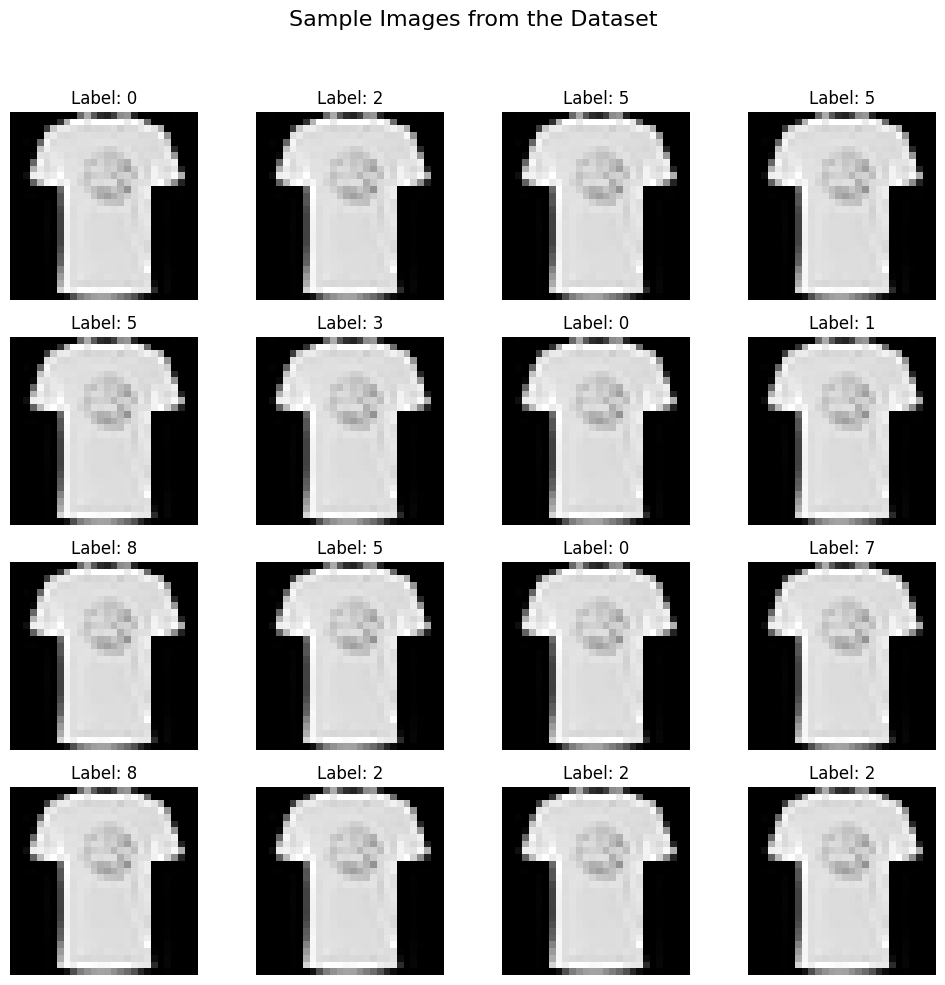

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Sample Images from the Dataset', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = train_small.iloc[0, 1:].values.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {train_small.iloc[i, 0]}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [7]:
X_train  = train_small.iloc[:, 1:].values
y_train = train_small.iloc[:, 0].values

X_test = test_small.iloc[:, 1:].values
y_test = test_small.iloc[:, 0].values

In [8]:
print(X_train.shape)  # (5000, 784)
print(y_train.shape)  # (5000,)
print(X_test.shape)   # (1000, 784)
print(y_test.shape)   # (1000,)


(5000, 784)
(5000,)
(1000, 784)
(1000,)


In [9]:
X_train = train_small.iloc[:, 1:].to_numpy(dtype="float32") / 255.0
X_test = test_small.iloc[:, 1:].to_numpy(dtype="float32") / 255.0

In [10]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [11]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [13]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
            # nn.softmax()   #no need to define explicitly automatically present
        )

    def forward(self, x):
        return self.model(x)
    

In [20]:
# Instantiate the model
epochs = 100
learning_rate = 0.01

In [21]:
# Instantiate the model
model = MyNN(X_train.shape[1])

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [22]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        #forward pass
        outputs = model(batch_features)

        #compute the loss
        loss = criterion(outputs, batch_labels)

        #backward pass
        optimizer.zero_grad()
        loss.backward()

        #update gradients and weights
        optimizer.step()
        total_epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch 1/100, Loss: 2.2376448379200733
Epoch 2/100, Loss: 1.9732042520668855
Epoch 3/100, Loss: 1.510929208652229
Epoch 4/100, Loss: 1.178487894641366
Epoch 5/100, Loss: 1.0001504409844708
Epoch 6/100, Loss: 0.8951990323461545
Epoch 7/100, Loss: 0.8314216543155112
Epoch 8/100, Loss: 0.784623245334929
Epoch 9/100, Loss: 0.7494930539541184
Epoch 10/100, Loss: 0.7222756458695527
Epoch 11/100, Loss: 0.697285488532607
Epoch 12/100, Loss: 0.6768351432624137
Epoch 13/100, Loss: 0.655264416887502
Epoch 14/100, Loss: 0.6413211801629157
Epoch 15/100, Loss: 0.6266130609497144
Epoch 16/100, Loss: 0.6097230239278951
Epoch 17/100, Loss: 0.5943970589121436
Epoch 18/100, Loss: 0.5810876715524941
Epoch 19/100, Loss: 0.5721855138897136
Epoch 20/100, Loss: 0.5611718541877285
Epoch 21/100, Loss: 0.5563772322645613
Epoch 22/100, Loss: 0.5441860885946614
Epoch 23/100, Loss: 0.5346691800150901
Epoch 24/100, Loss: 0.520927111529241
Epoch 25/100, Loss: 0.516120969584793
Epoch 26/100, Loss: 0.5066841981213563
Ep

In [23]:
# set model to evaluation mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
#evaluate the model on the test set
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f"Accuracy of the model on the test set: {100 * correct / total}%")

Accuracy of the model on the test set: 73.2%
